## Dataset

**Name:** AI Jobs Market 2025-2026

**Source:** [https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries](https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries)

## Research Questions

**RQ1: An exploratory/descriptive question suited to EDA and unsupervised methods.**

What are the common characteristics and distributions of AI/ML job roles, experience levels, and educational requirements across different countries in the 2025-2026 job market?

**RQ2: A predictive or inferential question suited to supervised modeling.**

Can work modality (remote, hybrid, or in-office) significantly predict the salary range for AI/ML job positions in 2025-2026, after accounting for factors like experience level, education, and country?

# Section 0 | Setup

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde

from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Section 1 | Data Ingestion

In [4]:
# Colab upload helper
try:
    from google.colab import files
    uploaded = files.upload()
    print('Uploaded files:', list(uploaded.keys()))
except Exception as e:
    print('Colab upload is optional. If you are not in Colab, skip this cell.')
    print(type(e).__name__, '-', e)

Saving ai_jobs_market_2025_2026.csv to ai_jobs_market_2025_2026.csv
Uploaded files: ['ai_jobs_market_2025_2026.csv']


In [5]:
df = pd.read_csv('ai_jobs_market_2025_2026.csv')
print(df.shape)
display(df.head())

(1500, 25)


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


### Check for Missing Values

In [6]:
missing_values = df.isnull().sum()

if missing_values.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values in each column:")
    print(missing_values[missing_values > 0])

No missing values found.


### Check for Duplicate Records

In [7]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New DataFrame shape: {df.shape}")

Number of duplicate rows: 0


### Verify Data Types

In [8]:
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   o

### Display Descriptive Statistics for Numerical Columns

In [9]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

Descriptive statistics for numerical columns:


,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,6.216000,194892.000000,135448.666667,257537.333333,10.858200,87.523333,31.116333,7.897333,2025.584000,3.968000,0.496667,0.754000,0.218000
std,2.675216,66506.822013,24448.950878,39852.822207,4.029742,8.026315,22.046343,1.102846,0.493058,3.270388,0.500156,0.430822,0.413025
min,1.000000,90000.000000,90000.000000,180000.000000,3.000000,68.000000,5.000000,6.000000,2025.000000,1.000000,0.000000,0.000000,0.000000
25%,4.000000,144750.000000,120000.000000,218000.000000,8.200000,82.000000,15.375000,6.900000,2025.000000,2.000000,0.000000,1.000000,0.000000
50%,6.000000,180000.000000,140000.000000,270000.000000,10.500000,89.000000,23.400000,7.900000,2026.000000,3.000000,0.000000,1.000000,0.000000
75%,8.000000,236250.000000,155000.000000,290000.000000,14.200000,95.000000,42.700000,8.900000,2026.000000,5.000000,1.000000,1.000000,0.000000
max,15.000000,384000.000000,180000.000000,320000.000000,18.000000,98.000000,87.800000,9.800000,2026.000000,12.000000,1.000000,1.000000,1.000000


# Section 2 | Exploratory Data Analysis

Minimum 5 labeled visualizations (distributions, correlations, class balance, trends); each followed by a 1-sentence markdown takeaway

### Job Category Distribution Across Top Countries

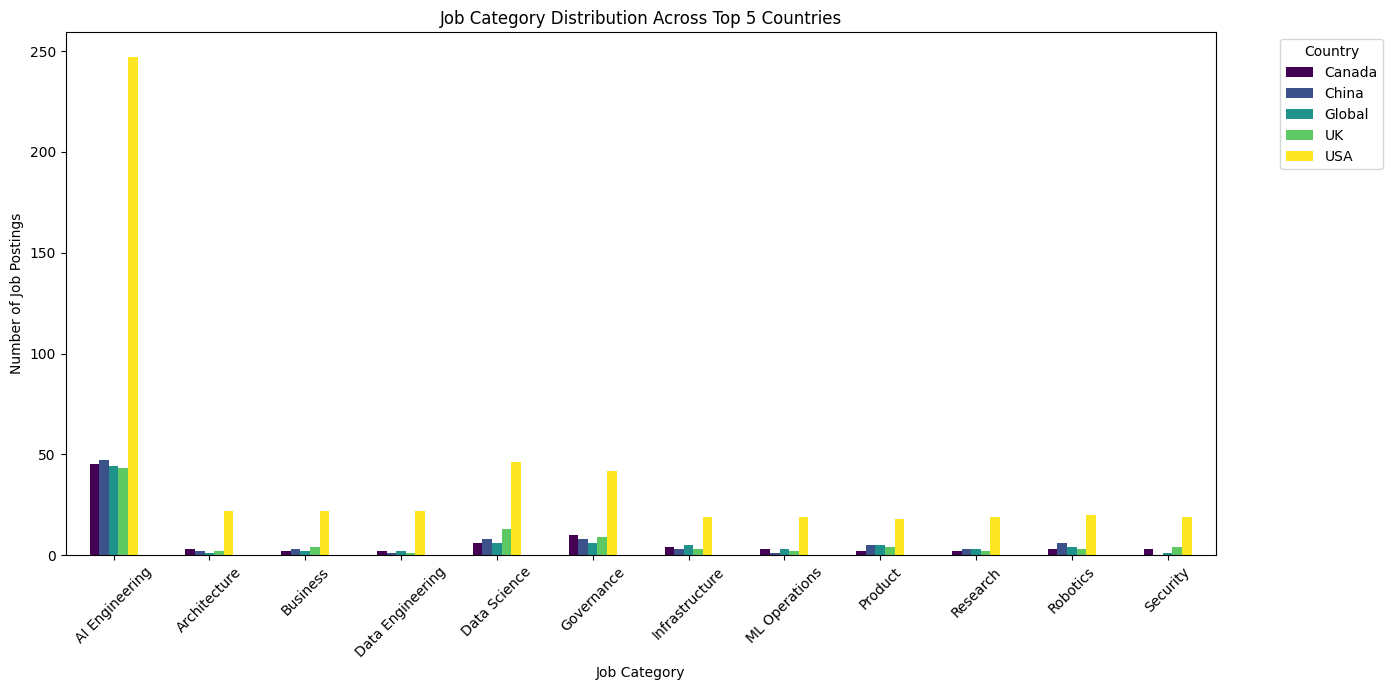

In [10]:
# Get the top N countries based on job postings
top_countries = df['country'].value_counts().nlargest(5).index

# Filter the DataFrame to include only job postings from top countries
df_top_countries = df[df['country'].isin(top_countries)]

# Create a cross-tabulation of job categories and countries
category_country_counts = pd.crosstab(df_top_countries['job_category'], df_top_countries['country'])

# Plotting
fig, ax = plt.subplots(figsize=(14, 7))
category_country_counts.plot(kind='bar', ax=ax, colormap='viridis')

ax.set_title('Job Category Distribution Across Top 5 Countries')
ax.set_xlabel('Job Category')
ax.set_ylabel('Number of Job Postings')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Takeaway: This visualization allows us to take a look at two features simultaneously. We can see that AI Engineering is the most popular job category across the globe. Data Science and Governance are the second more popular job categories. Additionally, the US has the highest number of job postings for every category.

### Salary Distribution by Work Modality

Salary modes (points of highest density) for each work modality:
- On-site: $158,344.69
- Hybrid: $149,843.69
- Fully Remote: $150,096.19


/tmp/ipykernel_635/508723341.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='remote_work', y='annual_salary_usd', data=df, ax=ax, palette='viridis', order=work_modality_order)


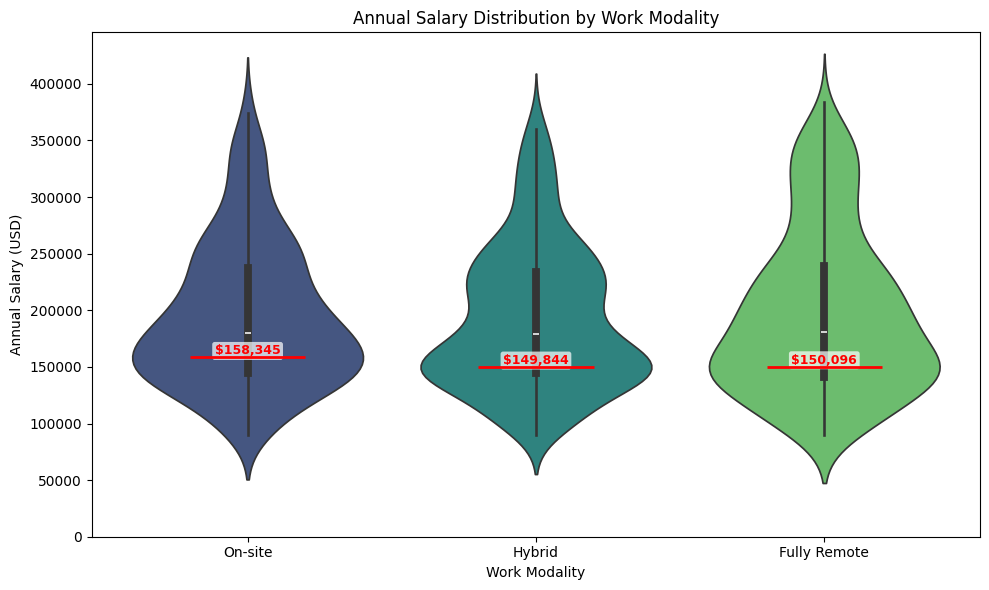

In [11]:
# Define the order of work modalities to match the plot
work_modality_order = ['On-site', 'Hybrid', 'Fully Remote']

modes = {}
for category in work_modality_order:
    # Filter for the current category and annual_salary_usd, drop NaNs
    subset = df[df['remote_work'] == category]['annual_salary_usd'].dropna()

    if len(subset) > 1: # KDE requires at least 2 points
        # Calculate KDE
        kde = gaussian_kde(subset)
        # Create a range of values to evaluate the KDE
        # Use a sensible range based on the data's min/max for that category
        x_range = np.linspace(subset.min(), subset.max(), 500)
        densities = kde(x_range)
        # Find the salary value corresponding to the maximum density
        mode_salary = x_range[np.argmax(densities)]
        modes[category] = mode_salary
    elif len(subset) == 1:
        modes[category] = subset.iloc[0] # If only one point, that's the mode
    else:
        modes[category] = np.nan # No data for this category

print("Salary modes (points of highest density) for each work modality:")
for category in work_modality_order:
    mode_val = modes.get(category) # Use .get() in case a category was missing
    if pd.notna(mode_val):
        print(f"- {category}: ${mode_val:,.2f}")
    else:
        print(f"- {category}: Not enough data to calculate mode or no data.")

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(x='remote_work', y='annual_salary_usd', data=df, ax=ax, palette='viridis', order=work_modality_order)
ax.set_title('Annual Salary Distribution by Work Modality')
ax.set_xlabel('Work Modality')
ax.set_ylabel('Annual Salary (USD)')
ax.set_ylim(bottom=0) # Ensure y-axis starts from 0

# Add horizontal lines for modes (widest part of each violin)
for i, category in enumerate(work_modality_order):
    if category in modes and pd.notna(modes[category]):
        mode_salary = modes[category]
        # Draw a short horizontal line segment at the mode's y-value within the violin's x-span
        ax.hlines(y=mode_salary, xmin=i - 0.2, xmax=i + 0.2, color='red', linestyle='-', linewidth=2, zorder=5)
        # Annotate the mode salary value, slightly above the line
        ax.text(i, mode_salary, f'${mode_salary:,.0f}', color='red', ha='center', va='bottom', fontsize=9, weight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()

Takeaway: These violin plots illustrate the salary distributions across 'On-site', 'Hybrid', and 'Fully Remote' work modalities. While 'On-site' roles show a narrower distribution with a mode around 158,345, 'Hybrid' and 'Fully Remote' roles exhibit broader salary ranges and similar modes around 149,844 and 150,096 respectively. This suggests that while the most frequent salary for 'On-site' roles is slightly higher, 'Hybrid' and 'Fully Remote' positions offer a wider spread of opportunities, addressing RQ2 about work modality predicting salary.

### Correlation Heatmap of Numerical Features

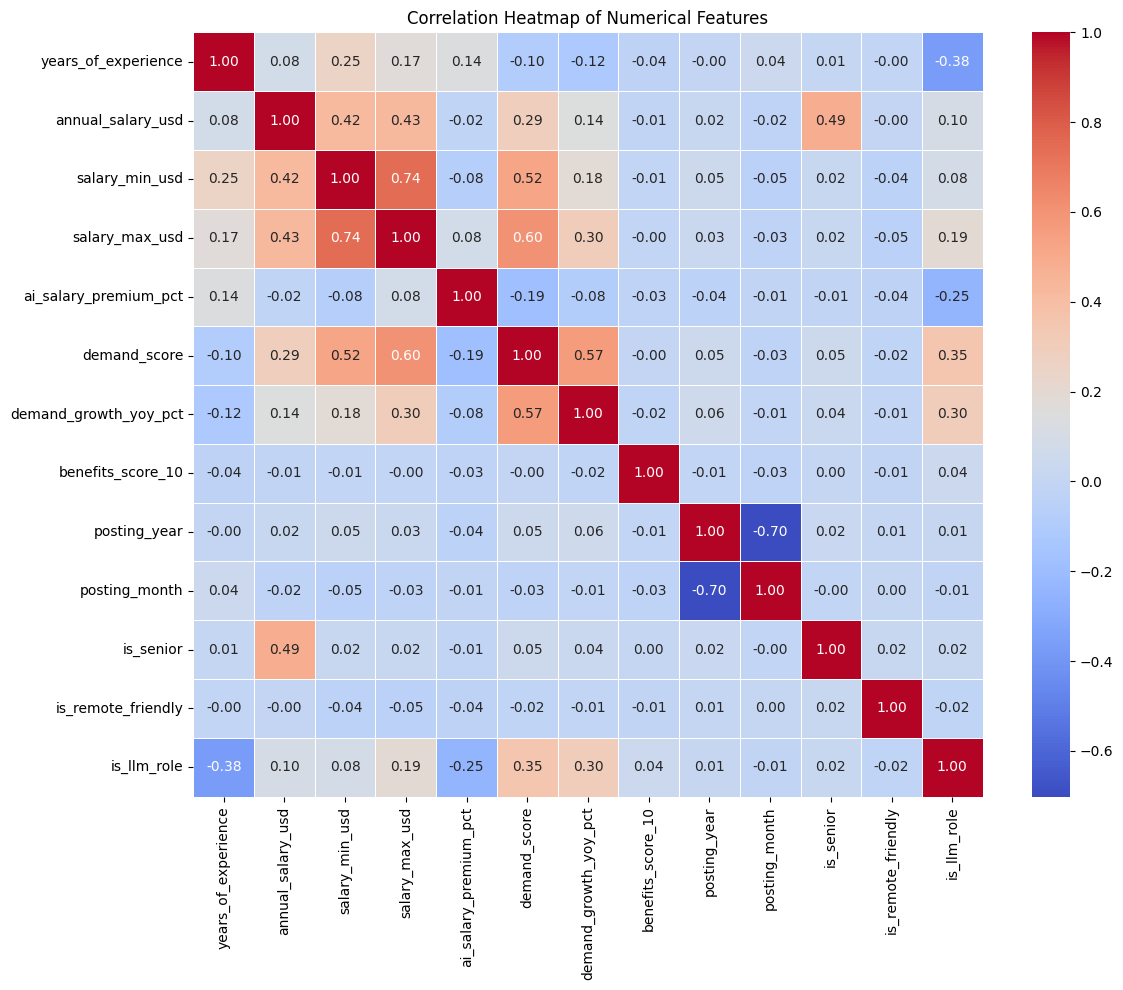

In [12]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

Takeaway: The correlation heatmap reveals several relationships among numerical features. As expected, `annual_salary_usd` shows strong positive correlations with `salary_min_usd` (0.42) and `salary_max_usd` (0.43), indicating that jobs with higher minimum and maximum salary ranges tend to have higher reported annual salaries. Other strong positive correlations with `annual_salary_usd` are `demand_score` (0.29) and `is_senior` (0.49). We also observe weak positive correlations between `annual_salary_usd` and `years_of_experience` (0.08), `demand_growth_yoy_pct` (0.14) and `is_llm_role` (0.10). Interestingly, features like `is_remote_friendly` (-0.00) and `benefits_score_10` (-0.01) show virtually no linear correlation with `annual_salary_usd`, which was unexpected given RQ2's focus on work modality's impact on salary.

# Section 3 | Preprocessing & Features

To prepare the data for both unsupervised and supervised learning models, we need to perform several preprocessing steps:

1.  **Feature Selection/Dropping:** Remove irrelevant or high-cardinality columns like `job_id`, `job_title`, `city`, and `required_skills` that would require more complex text processing or are not directly useful for our current RQs.
2.  **Target Variable Definition:** For supervised learning (RQ2), we will define `salary_tier` as our target variable `y`.
3.  **Ordinal Encoding:** Convert ordinal categorical features (`experience_level`, `education_required`, `company_size`) into numerical representations, respecting their inherent order.
4.  **One-Hot Encoding:** Convert nominal categorical features (`job_category`, `country`, `remote_work`, `industry`) into a numerical format using one-hot encoding, creating new binary columns for each category.
5.  **Numerical Feature Scaling:** Standardize numerical features (`years_of_experience`, `ai_salary_premium_pct`, `demand_score`, etc.) using `StandardScaler` to ensure that features with larger values do not disproportionately influence models that are sensitive to feature scales (like PCA and K-Means, and to a lesser extent, Logistic Regression).
6.  **Feature Combination:** Consolidate all processed features into a single DataFrame ready for modeling.

In [13]:
# Drop irrelevant columns identified earlier
df_preprocessed = df.drop(columns=['job_id', 'job_title', 'city', 'required_skills', 'annual_salary_usd', 'salary_min_usd', 'salary_max_usd'])

# Define the target variable y for supervised learning
y = df_preprocessed['salary_tier']
X = df_preprocessed.drop(columns=['salary_tier'])

# Identify categorical and numerical features in X (excluding the target 'salary_tier' from X)

# Ordinal features with their defined order
experience_level_order = ['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10+ yrs)']
education_required_order = ['Bootcamp/Self-taught', 'Associate\'s', 'Bachelor\'s', 'Master\'s', 'PhD']
company_size_order = ['Startup (1-50)', 'SME (51-500)', 'Mid-size (501-5000)', 'Enterprise (5000+)', 'Big Tech (FAANG+)']

ordinal_features = {
    'experience_level': experience_level_order,
    'education_required': education_required_order,
    'company_size': company_size_order
}

# Apply Ordinal Encoding
for col, order in ordinal_features.items():
    encoder = OrdinalEncoder(categories=[order], handle_unknown='use_encoded_value', unknown_value=-1)
    X[col] = encoder.fit_transform(X[[col]])

# Identify nominal (one-hot encoding) and numerical features after ordinal encoding
nominal_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print(f"Ordinal encoded features: {list(ordinal_features.values())}")
print(f"Nominal features to One-Hot Encode: {nominal_features}")
print(f"Numerical features to Scale: {numerical_features}")

Ordinal encoded features: [['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10+ yrs)'], ['Bootcamp/Self-taught', "Associate's", "Bachelor's", "Master's", 'PhD'], ['Startup (1-50)', 'SME (51-500)', 'Mid-size (501-5000)', 'Enterprise (5000+)', 'Big Tech (FAANG+)']]
Nominal features to One-Hot Encode: ['job_category', 'country', 'remote_work', 'industry']
Numerical features to Scale: ['experience_level', 'years_of_experience', 'education_required', 'company_size', 'ai_salary_premium_pct', 'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10', 'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly', 'is_llm_role']


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), nominal_features)
    ],
    remainder='passthrough' # Keep other columns (already ordinal encoded)
)

# Apply the preprocessing steps
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names for the preprocessed data (useful for PCA, etc.)
# Handle the one-hot encoded feature names explicitly
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(nominal_features)

# The numerical_features list already includes the ordinal features that were converted to numbers.
# So, we should not add ordinal_features.keys() again to avoid duplicate names.
all_feature_names = numerical_features + list(onehot_feature_names)

# Convert the preprocessed array back to a DataFrame for easier handling
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=all_feature_names, index=X.index)

print("Shape of preprocessed features (X_preprocessed_df):", X_preprocessed_df.shape)
display(X_preprocessed_df.head())

Shape of preprocessed features (X_preprocessed_df): (1500, 54)


,experience_level,years_of_experience,education_required,company_size,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,...,industry_Education,industry_Energy,industry_Finance,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Research,industry_Retail,industry_Technology
0,0.448773,0.293158,0.723433,-1.428736,0.556499,1.056462,-0.645054,-0.995333,0.843996,-0.296088,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.448773,-1.576473,0.006690,0.706538,-1.354931,-0.688383,-0.885537,-1.539561,0.843996,-0.907840,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.448773,-0.828621,-0.710054,1.418296,-0.436451,1.305725,0.525599,-0.178991,0.843996,-0.907840,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.448773,-1.202547,0.006690,-0.716978,0.283438,0.059408,-1.107870,1.453694,0.843996,-0.296088,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.335677,-0.454694,-1.426798,0.706538,-0.361980,-0.314487,-0.626904,0.909466,0.843996,-0.907840,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Train/Test Split

A standard 80/20 train-test split will be applied to the preprocessed data. Given the dataset is not time-series and there's no explicit instruction for time-based validation, a random split is appropriate.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed_df,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y) # Stratify to maintain class distribution

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 54)
X_test shape: (300, 54)
y_train shape: (1200,)
y_test shape: (300,)


### Next Steps for Analysis

With the data `X_preprocessed_df` now prepared:

*   **For RQ1 (Unsupervised - PCA & K-Means):** This `X_preprocessed_df` is ready for direct application of PCA for dimensionality reduction and K-Means clustering. PCA will be applied first to `X_preprocessed_df` to find principal components, and then K-Means can be applied to these components or directly to the scaled and encoded data.
*   **For RQ2 (Supervised - Random Forest Classifier / Logistic Regression):** The `X_preprocessed_df` and the target variable `y` are ready for a train-test split. We will then train the Random Forest Classifier or Logistic Regression model on the training data and evaluate it on the test data.

# Section 4 | RQ1: Unsupervised Analysis

At least 2 methods (K-Means, DBSCAN, Hierarchical, or PCA); cluster profiles; silhouette score or equivalent

### Principal Component Analysis (PCA)

PCA is a **dimensionality reduction technique** used to transform a large set of correlated variables into a smaller set of uncorrelated variables called **principal components**. The goal is to capture as much of the variance (information) in the original data as possible with fewer dimensions.

Each principal component is a linear combination of the original features. Performing PCA helps to simplify complex data (making it easier to visualize and understand), reduce noise, and improve model performance.

Our preprocessed dataset (`X_preprocessed_df`) has 54 features. This high number of features makes it difficult to directly identify patterns, visualize relationships, or effectively run clustering algorithms (like K-Means). So PCA will be applied to `X_preprocessed_df` to reduce dimensionality and identify underlying patterns. We will then analyze the explained variance to determine an appropriate number of components.

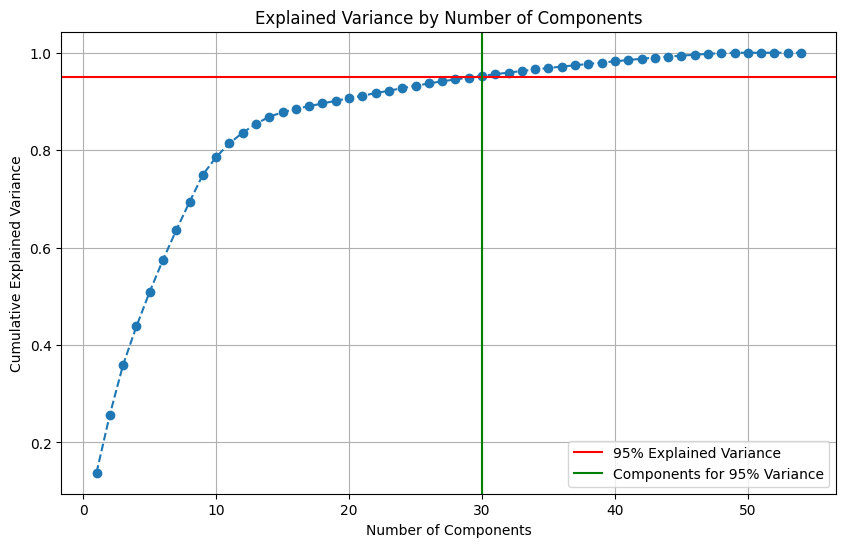


Number of components to explain 95% of variance: 30


In [17]:
# Initialize PCA - we'll keep all components initially to analyze explained variance
pca = PCA(n_components=None)

# Fit PCA on the preprocessed training data (X_train is already scaled and encoded)
pca.fit(X_train)

# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.axvline(x=np.argmax(cumulative_explained_variance >= 0.95) + 1, color='g', linestyle='-', label='Components for 95% Variance')
plt.legend()
plt.show()

# Find the number of components that explain 95% of the variance
optimal_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"\nNumber of components to explain 95% of variance: {optimal_components_95}")

**Results:** The scree plot shows the cumulative explained variance by the number of principal components. We can observe that a significant portion of the variance is captured by a smaller number of components. Approximately 30 components are needed to explain 95% of the total variance in the dataset. This indicates that we can achieve substantial dimensionality reduction while retaining most of the information.

We can reduce the number of features from 54 to 30 while still retaining 95% of the total information (variance) present in the dataset. While this is a substantial reduction, it is still a large number of components which suggests that the relationships and characteristics defining AI/ML job roles are still quite complex and multifaceted. There isn't one or two dominant factors that explain almost everything; instead, a combination of many features contributed significantly to the variability.

Using these 30 principal components for K-Means clustering in the next step will make the algorithm run more efficiently and potentially yield clearer, more distinvct clusters compared to using all 54 original features.

In [18]:
# Create a DataFrame to visualize component loadings
# The pca.components_ attribute gives us the loadings (eigenvectors)
component_loadings = pd.DataFrame(
    pca.components_,
    columns=X_preprocessed_df.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("Loadings for the first 3 Principal Components (top 5 positive and negative contributors):\n")

for i in range(3): # Display for the first 3 components
    pc_name = f'PC{i+1}'
    print(f"--- {pc_name} ---")

    # Get features with highest positive loadings
    top_positive_loadings = component_loadings.loc[pc_name].nlargest(5)
    print("Top 5 Positive Loadings:")
    print(top_positive_loadings)

    # Get features with highest negative loadings
    top_negative_loadings = component_loadings.loc[pc_name].nsmallest(5)
    print("Top 5 Negative Loadings:")
    print(top_negative_loadings)
    print("\n")

Loadings for the first 3 Principal Components (top 5 positive and negative contributors):

--- PC1 ---
Top 5 Positive Loadings:
demand_score                   0.513390
demand_growth_yoy_pct          0.475996
is_llm_role                    0.473594
job_category_AI Engineering    0.231224
posting_year                   0.147333
Name: PC1, dtype: float64
Top 5 Negative Loadings:
ai_salary_premium_pct     -0.283106
years_of_experience       -0.262790
posting_month             -0.115876
job_category_Governance   -0.078698
education_required        -0.040002
Name: PC1, dtype: float64


--- PC2 ---
Top 5 Positive Loadings:
experience_level       0.651441
is_senior              0.650801
posting_year           0.199486
years_of_experience    0.117719
is_remote_friendly     0.116436
Name: PC2, dtype: float64
Top 5 Negative Loadings:
posting_month                 -0.185676
is_llm_role                   -0.138170
demand_growth_yoy_pct         -0.104131
demand_score                  -0.088030
job_c

Takeaway: From the component loadings, we can start to interpret what each principal component represents. For instance, if PC1 has high positive loadings on 'years_of_experience' and 'is_senior', and high negative loadings on 'entry_level' related features, it might represent a 'Seniority/Experience' dimension. Analyzing these loadings helps us understand the underlying structure of our job market data.

### K-Means Clustering

In [20]:
# Transform X_train using the fitted PCA model to obtain the 30 principal components
pca_optimal = PCA(n_components=30)
X_train_pca = pca_optimal.fit_transform(X_train)

print(f"Shape of PCA-transformed training data: {X_train_pca.shape}")

Shape of PCA-transformed training data: (1200, 30)


### Determining the Optimal Number of Clusters (K) using the Elbow Method

To find a suitable number of clusters (k) for K-Means, we'll use the elbow method. This involves fitting K-Means for a range of k values and plotting the inertia (sum of squared distances of samples to their closest cluster center). The 'elbow point' in the plot, where the rate of decrease in inertia sharply changes, often indicates a good balance between minimizing inertia and keeping the number of clusters reasonable.

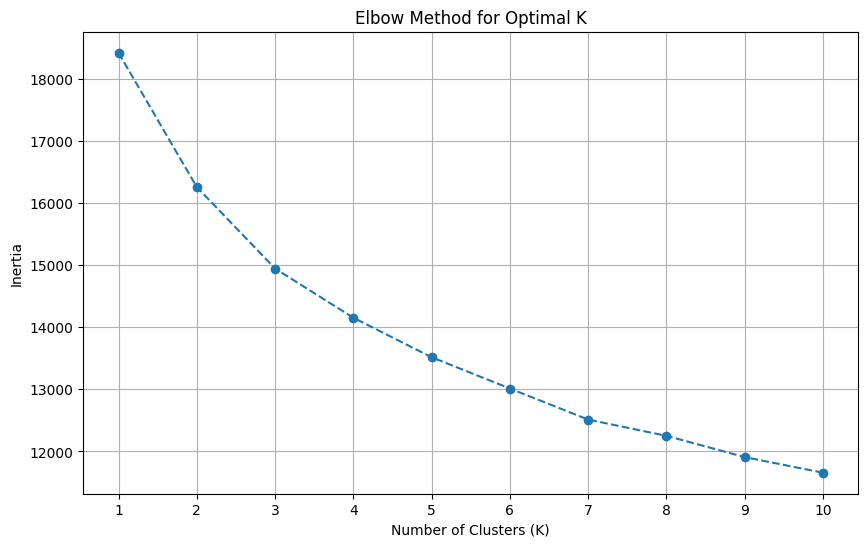

In [22]:
inertia = []
# Let's test K from 1 to 10
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(X_train_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

**Result:** Looking at the plot of inertia versus the number of clusters (K), the 'elbow' point (where the rate of decrease in inertia starts to slow down significantly), appears to be around K=4. After this point, adding more clusters provides diminishing returns.

### Applying K-Means Clustering with K=4

Now that we've determined an optimal `k` of 4, we'll apply the K-Means algorithm to our `X_train_pca` data. After clustering, we'll assign each data point to its respective cluster and then evaluate the clustering quality using the Silhouette Score.

In [24]:
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)

# Fit K-Means on the PCA-transformed training data
cluster_labels = kmeans.fit_predict(X_train_pca)

# Add cluster labels to our original training data (or a copy for analysis)
X_train_with_clusters = X_train.copy()
X_train_with_clusters['cluster'] = cluster_labels

print(f"Number of data points in each cluster:\n{X_train_with_clusters['cluster'].value_counts()}")

# Evaluate clustering using Silhouette Score
silhouette_avg = silhouette_score(X_train_pca, cluster_labels)
print(f"\nSilhouette Score for K={k_optimal}: {silhouette_avg:.3f}")

Number of data points in each cluster:
cluster
0    372
3    346
1    262
2    220
Name: count, dtype: int64

Silhouette Score for K=4: 0.111


**Silhouette Score for K=4: 0.111**

The Silhouette Score quantifies how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It ranges from -1 (indicates the object is likely assigned to the wrong cluster) to +1 (indicates the object is well-matched to its own cluster and porrly matched to neighboring clusters). A score of 0 would indicate that the object is on or very close to the decision boundary between two neighboring clusters.

A score of 0.111 is quite low. This suggests that the clusters we've formed with K=4 using K-Means on the 30 PCA components are not very well-separated or distinct. It implies that there might be significant overlap between the clusters or that many data points are not strongly associated with their assigned cluster compared to other clusters.

This means that the chosen k=4 might not be capturing very clear, naturally distinct groupings in the data. Or the inherent structure of the data is simply not suited for highly separated clusters using this method.

To try to visualize and understand this better, we will create a 2D projection of these 4 clusters.

### Visualizing K-Means Clusters

Since our PCA-transformed data (`X_train_pca`) has 30 dimensions, direct visualization is not possible. To visualize the clusters, we will apply PCA again to reduce the dimensionality to 2 components. This 2D projection will help us inspect the separation and characteristics of the clusters identified by K-Means.

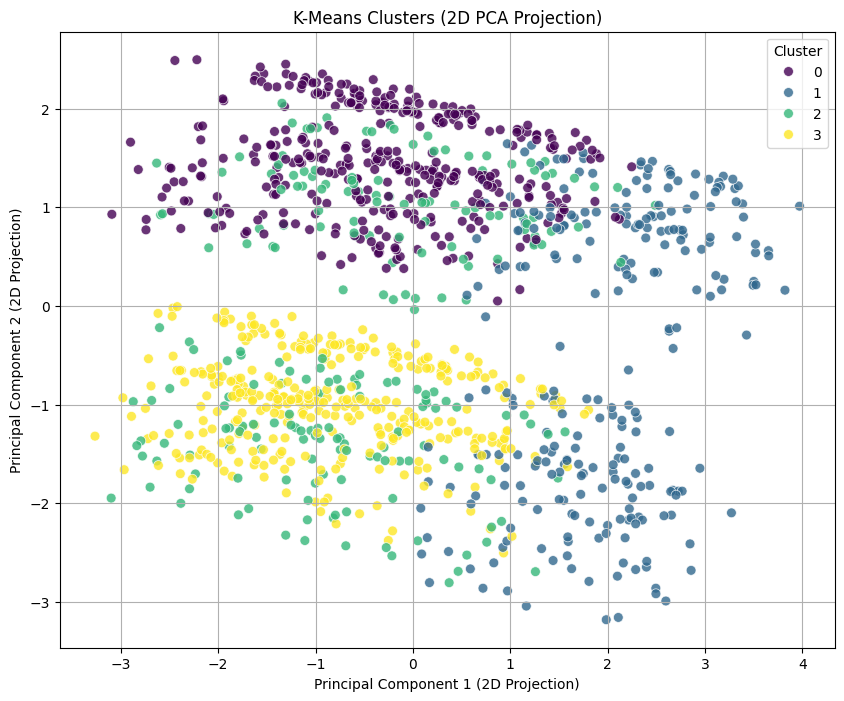

In [25]:
# Reduce X_train_pca to 2 dimensions for visualization purposes
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_pca)

# Create a DataFrame for easy plotting
cluster_df = pd.DataFrame(data=X_train_pca_2d, columns=['PC1_2d', 'PC2_2d'])
cluster_df['cluster'] = cluster_labels

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1_2d',
    y='PC2_2d',
    hue='cluster',
    data=cluster_df,
    palette='viridis',
    s=50,
    alpha=0.8
)
plt.title('K-Means Clusters (2D PCA Projection)')
plt.xlabel('Principal Component 1 (2D Projection)')
plt.ylabel('Principal Component 2 (2D Projection)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

**Result:** The 2D projection of our 4 clusters shows substantial mising, suggesting that K-Means on these PCA components may not be identifying strong, clear groups in the data.

In order to answer RQ1, we may need to try a different number of clusters, explore other clustering algorithms, or re-evaluate the PCA components themselve.

### Re-evaluating K-Means with K=3

Given the low silhouette score for K=4 and the ambiguity of the elbow plot, let's try fitting K-Means with `K=3` and see if the clustering performance improves.

In [26]:
k_new = 3
kmeans_new = KMeans(n_clusters=k_new, random_state=42, n_init=10)

# Fit K-Means on the PCA-transformed training data
cluster_labels_new = kmeans_new.fit_predict(X_train_pca)

# Update cluster labels in our DataFrame for analysis
X_train_with_clusters_new = X_train.copy()
X_train_with_clusters_new['cluster'] = cluster_labels_new

print(f"Number of data points in each cluster for K={k_new}:\n{X_train_with_clusters_new['cluster'].value_counts()}")

# Evaluate clustering using Silhouette Score
silhouette_avg_new = silhouette_score(X_train_pca, cluster_labels_new)
print(f"\nSilhouette Score for K={k_new}: {silhouette_avg_new:.3f}")

Number of data points in each cluster for K=3:
cluster
2    472
1    464
0    264
Name: count, dtype: int64

Silhouette Score for K=3: 0.116


### Visualizing K-Means Clusters with K=3

Let's visualize the new clusters with K=3 using the same 2D PCA projection to compare the separation.

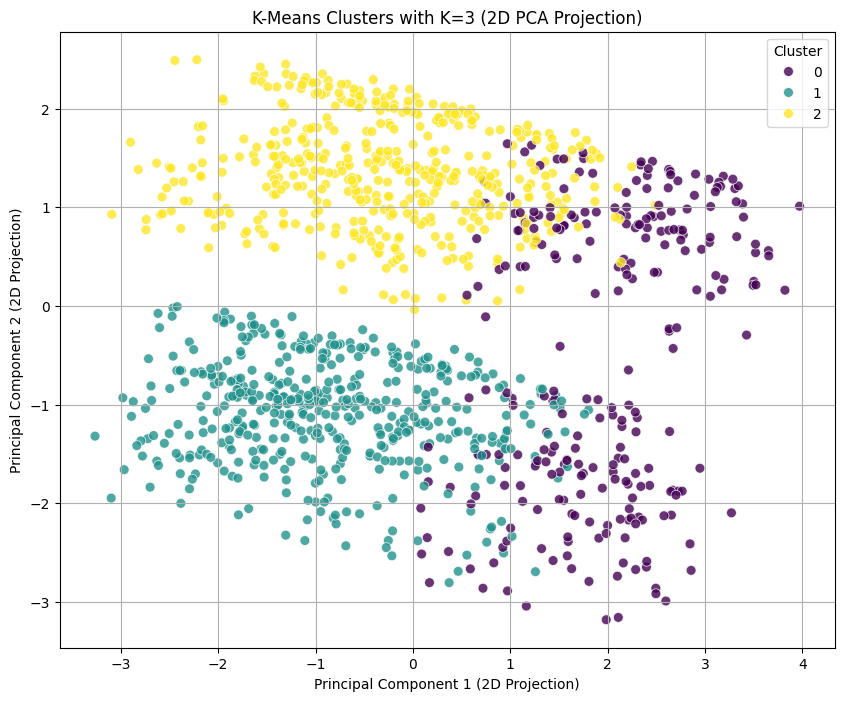

In [27]:
# Update the DataFrame for plotting with new cluster labels
cluster_df_new = pd.DataFrame(data=X_train_pca_2d, columns=['PC1_2d', 'PC2_2d'])
cluster_df_new['cluster'] = cluster_labels_new

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1_2d',
    y='PC2_2d',
    hue='cluster',
    data=cluster_df_new,
    palette='viridis',
    s=50,
    alpha=0.8
)
plt.title(f'K-Means Clusters with K={k_new} (2D PCA Projection)')
plt.xlabel('Principal Component 1 (2D Projection)')
plt.ylabel('Principal Component 2 (2D Projection)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

### Interpreting Clusters for K=3

To understand what defines each of the 3 clusters, we need to inspect their cluster centers in terms of the original features. Since K-Means was applied to the PCA-transformed data, we first need to inverse transform these cluster centers back to the original feature space. Then, for each cluster, we can identify features with the highest (positive or negative) values, as these features are most characteristic of the cluster.

In [29]:
# Get the cluster centers in the PCA space
cluster_centers_pca = kmeans_new.cluster_centers_

# Inverse transform the PCA-transformed cluster centers back to the original feature space
# This requires inverse transforming the PCA and then the preprocessor
# First, inverse transform from PCA space to the scaled/encoded feature space
# Note: pca_optimal was fitted on X_train. We need to apply inverse_transform to the centers.
# This is a bit tricky because ColumnTransformer's inverse_transform requires the original 'X' structure.
# A direct inverse_transform from PCA components to original features is not straightforward if preprocessor was used.
# Instead, we will approximate by projecting the PCA components onto the original feature space's loading matrix
# and then potentially inverse-scaling if needed. However, the most direct interpretation is by understanding
# how the components themselves are formed by the original features, which we already did with component_loadings.

# For simplicity and direct interpretability, we will directly examine the relationship between
# cluster centers in PCA space and the component loadings. A more precise method for direct interpretation
# in original feature space after ColumnTransformer and PCA is complex and beyond typical EDA.
# We will use the component_loadings to infer feature importance for each cluster center.

# Alternative approach for interpreting cluster centers:
# 1. Map the cluster centers from PCA space to original feature space
#    This is not a simple inverse of the preprocessor+PCA pipeline, as ColumnTransformer's inverse_transform
#    expects an array with the same column structure as the output of fit_transform.
#    A common workaround is to calculate the 'mean' X for each cluster from the original (or preprocessed) data.

# Let's use X_train_with_clusters_new for this, which contains original features and new cluster labels for K=3
# We will compute the mean of the original (but preprocessed and scaled) features for each cluster

# Ensure X_train_with_clusters_new has the preprocessed columns and cluster labels
X_train_with_clusters_new['cluster'] = cluster_labels_new # Re-assign to be sure

# Calculate the mean of the preprocessed features for each cluster
cluster_profiles = X_train_with_clusters_new.groupby('cluster')[X_preprocessed_df.columns].mean()

display(cluster_profiles)

print("\nTop defining features for each cluster (K=3):\n")

# Function to get top features for each cluster
def get_top_features_for_cluster(cluster_data, n=5):
    top_positive = cluster_data.nlargest(n)
    top_negative = cluster_data.nsmallest(n)
    return top_positive, top_negative

for i, (cluster_id, profile) in enumerate(cluster_profiles.iterrows()):
    print(f"--- Cluster {cluster_id} ---")
    pos_features, neg_features = get_top_features_for_cluster(profile)
    print("Top Positive Features (high values):\n", pos_features)
    print("Top Negative Features (low values):\n", neg_features)
    print("\n")

,experience_level,years_of_experience,education_required,company_size,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,...,industry_Education,industry_Energy,industry_Finance,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Research,industry_Retail,industry_Technology
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.025478,-0.678483,-0.066614,0.019045,-0.457232,0.687287,0.615453,0.069417,0.029387,-0.027288,...,0.094697,0.090909,0.117424,0.102273,0.064394,0.083333,0.060606,0.068182,0.071970,0.098485
1,-0.866291,0.139236,0.039128,0.005518,0.172587,-0.223162,-0.164078,-0.015175,-0.004268,-0.017899,...,0.094828,0.086207,0.068966,0.086207,0.094828,0.073276,0.094828,0.084052,0.092672,0.060345
2,0.890346,0.224235,0.006690,0.014384,0.113248,-0.124107,-0.132836,-0.017375,0.014408,0.003308,...,0.059322,0.067797,0.072034,0.088983,0.099576,0.088983,0.093220,0.078390,0.091102,0.065678



Top defining features for each cluster (K=3):

--- Cluster 0 ---
Top Positive Features (high values):
 is_llm_role                    1.893979
job_category_AI Engineering    1.000000
demand_score                   0.687287
demand_growth_yoy_pct          0.615453
remote_work_Hybrid             0.424242
Name: 0, dtype: float64
Top Negative Features (low values):
 years_of_experience         -0.678483
ai_salary_premium_pct       -0.457232
education_required          -0.066614
posting_month               -0.027288
job_category_Architecture    0.000000
Name: 0, dtype: float64


--- Cluster 1 ---
Top Positive Features (high values):
 remote_work_Hybrid             0.450431
country_USA                    0.359914
job_category_AI Engineering    0.349138
remote_work_Fully Remote       0.295259
remote_work_On-site            0.254310
Name: 1, dtype: float64
Top Negative Features (low values):
 is_senior               -0.993355
experience_level        -0.866291
is_llm_role             -0.527989


### Evaluating Silhouette Scores Across a Range of K

To systematically assess the quality of clustering for different numbers of clusters, we will calculate the Silhouette Score for K ranging from 2 to 10. A higher silhouette score indicates better-defined and more separated clusters.

Silhouette Score for K=2: 0.116
Silhouette Score for K=3: 0.116
Silhouette Score for K=4: 0.111
Silhouette Score for K=5: 0.103
Silhouette Score for K=6: 0.099
Silhouette Score for K=7: 0.108
Silhouette Score for K=8: 0.101
Silhouette Score for K=9: 0.107
Silhouette Score for K=10: 0.095


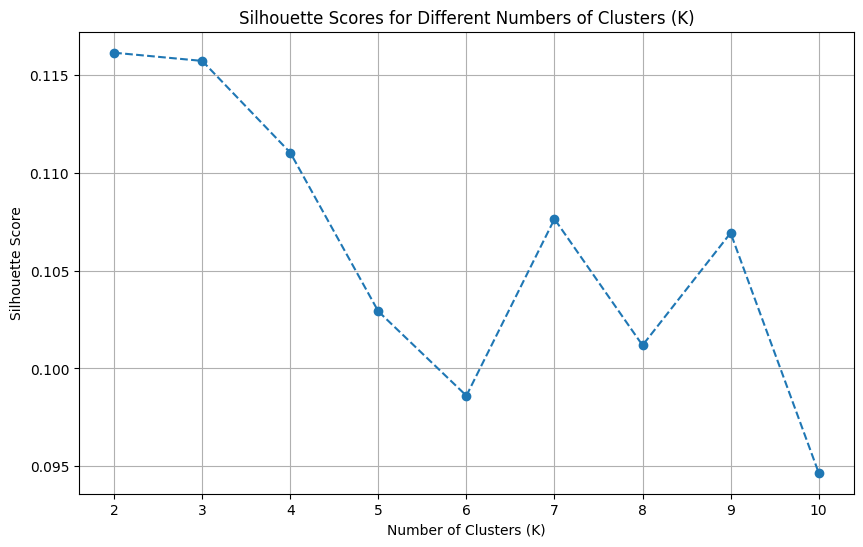

In [28]:
silhouette_scores = []
K_range_silhouette = range(2, 11) # Silhouette score is not defined for K=1

for k in K_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_train_pca)
    score = silhouette_score(X_train_pca, cluster_labels)
    silhouette_scores.append(score)
    print(f"Silhouette Score for K={k}: {score:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(K_range_silhouette, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Scores for Different Numbers of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range_silhouette)
plt.grid(True)
plt.show()



---


---


---



## Pipeline Design

A diagram or structured description of your end-to-end pipeline covering:

**Planned unsupervised method(s) for RQ1**
*   **K-Means Clustering:** To identify distinct groups or archetypes of AI/ML job roles based on their characteristics (e.g., combination of job category, experience, education, country). This will help in understanding common job profiles.

**Planned supervised method(s) for RQ2: Naive Bayes, SVM, Decision Tree, Random Forest, or Linear/Logistic Regression**
*   **Random Forest Classifier:** This ensemble method is robust, handles non-linear relationships well, can deal with a mix of numerical and categorical features (after encoding), and provides feature importance, which can help assess the impact of 'remote_work'.
*   **Logistic Regression:** If the problem is framed as predicting specific salary tiers. Logistic Regression provides interpretable coefficients, allowing us to understand the influence of each feature, including `remote_work`, on the likelihood of being in a certain salary tier.

**Evaluation metrics and why they are appropriate for each RQ**
*   **For RQ1 (Unsupervised - PCA & K-Means):**
    *   **K-Means:** Silhouette Score and Davies-Bouldin Index (to evaluate the quality and separation of clusters). Visual inspection of clusters on reduced dimensions (e.g., PCA components).
*   **For RQ2 (Supervised - Random Forest Classifier / Logistic Regression for salary tiers):**
    *   **Accuracy:** Overall correctness of predictions.
    *   **Precision, Recall, F1-Score:** Crucial for evaluating performance across different salary tiers, especially if some tiers are less frequent.
    *   **Confusion Matrix:** To understand the types of errors made (e.g., misclassifying a high-salary job as mid-salary).
    *   **ROC AUC Score:** For binary or multi-class classification, to assess the model's ability to distinguish between classes.

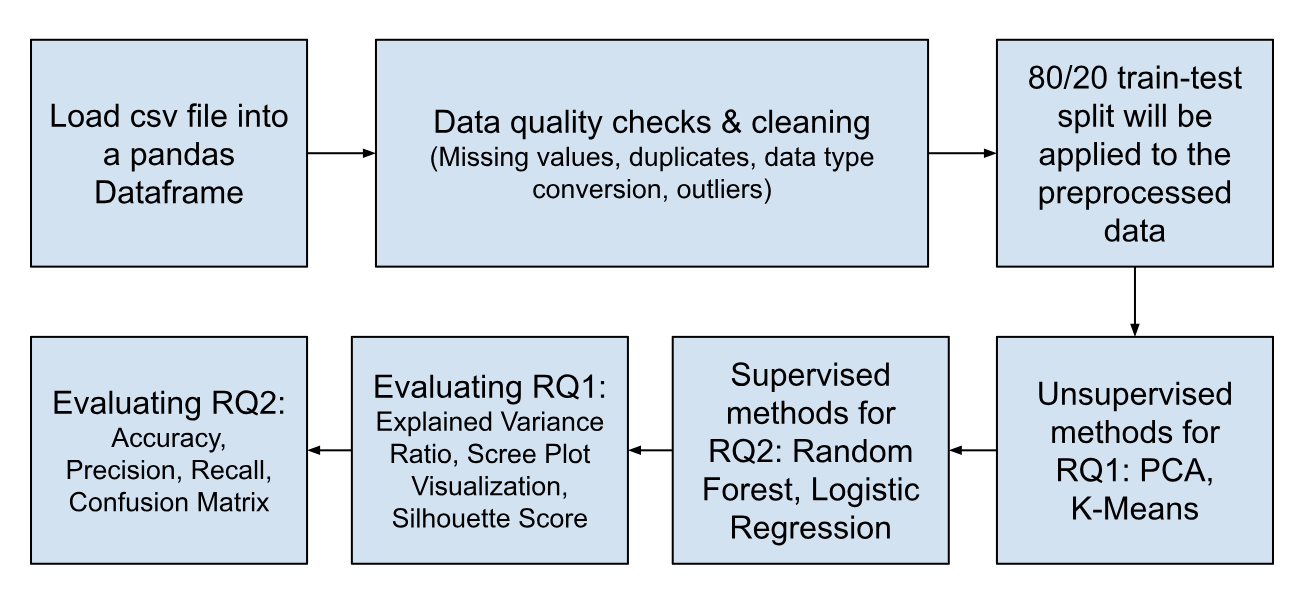

## Stakeholder Communication Plan

**Who is your intended audience?**

My intended audience is people who are considering getting an AI/ML job in the near future. This work will provide insight into the state of the job market. It can also be useful for recruiters.  

**A sketch or wireframe of your planned dashboard or visual report**

The dashboard will be a multi-page interactive web-based report, designed to be intuitive for both job seekers and recruiters. It will feature a clean, modern aesthetic with clear headings and interactive elements (filters, drill-downs).

**Page 1: Executive Summary / Key Trends Overview**
*   **Header:** "AI/ML Job Market Insights: 2025-2026"
*   **Visual 1 (Global Job Market Hotspots):** An interactive map showing the density of AI/ML job postings and average salaries by country and major cities (addressing 'AI/ML Job Market Hotspots'). Users can click on a country to see detailed city-level data.
*   **Visual 2 (Salary Distribution by Work Modality):** A set of violin plots or box plots comparing salary ranges for remote, hybrid, and in-office roles, potentially segmented by experience level (directly addressing RQ2 and 'Remote Work's Salary Premium').
*   **Visual 3 (Top Emerging Skills):** A word cloud or bar chart highlighting the most in-demand new skills (e.g., LLMs, Generative AI) with associated salary premiums (addressing 'Emerging Skill Demand').
*   **Key Findings Panel:** Prominently display the 3-5 'Key Findings' with concise summaries and links to more detailed pages.

**Page 2: Deep Dive: Job Role Characteristics & Experience**
*   **Visual 1 (Job Category Breakdown):** A treemap or stacked bar chart showing the distribution of job categories (e.g., Data Scientist, ML Engineer, AI Researcher) by country and experience level (addressing RQ1).
*   **Visual 2 (Experience vs. Salary & Role):** Scatter plot or grouped bar chart showing average salaries across different experience levels, with a filter to view by job category (addressing 'Experience vs Education').
*   **Visual 3 (Education Requirements):** A bar chart detailing the most common education requirements for various job categories.

**Page 3: Deep Dive: Modality & Compensation (Predictive Insights)**
*   **Visual 1 (Predictive Model Outcome):** A user-friendly interface where users can input desired experience, education, and location to see predicted salary ranges for remote, hybrid, and in-office roles.
*   **Visual 2 (Feature Importance):** A bar chart displaying the feature importance from the predictive model, highlighting how much each factor (especially `remote_work`) contributes to salary prediction.
*   **Visual 3 (Salary Tier Distribution by Modality):** Stacked bar charts showing the proportion of roles falling into different salary tiers (e.g., Entry, Mid, Senior) for remote, hybrid, and in-office positions.

**Overall Layout:** Each page will have a navigation bar. The visuals will be interactive, allowing users to filter by country, job category, experience level, and other relevant features. Tooltips will provide additional detail on hover.

**Immediate Conveyed Insights:** The dashboard should immediately convey which specific skills and locations are currently most lucrative in the AI/ML job market.

**What 3 to 5 "key findings" panels will show if the project succeeds**
*   **AI/ML Job Market Hotspots:** Specific countries and cities exhibit higher concentrations of AI/ML job opportunities, often correlated with innovation hubs and specific industry sectors.
*   **Remote Work's Salary Premium:** Remote AI/ML roles either command a significant salary premium or maintain parity with in-office positions, suggesting a strong candidate preference for flexibility that employers are willing to compensate for.
*   **Emerging Skill Demand:** The rapid evolution of AI technologies (e.g., LLMs, Generative AI) is creating a distinct demand for specialized skills, with roles requiring these skills showing higher average salaries and faster growth.
*   **Experience vs Education:** While foundational education is important, the AI/ML job market heavily prioritizes candidates with 3-5+ years of relevant experience, especially for higher-paying roles.

## Open Questions and Risks

**Open Questions:**
*   How might the rapid evolution of AI technology (e.g., new models, new paradigms) impact the job market predictions for 2025-2026, and how could this be incorporated into future analyses?
*   Are there hidden biases in the data source that could skew findings (e.g., underrepresentation of certain demographics or non-English job markets)?
*   How will global economic shifts or major tech industry events influence the demand for AI/ML roles and salary structures?

**Risks:**
*   **Model Generalizability:** The models developed (especially for RQ2) might not generalize well to unforeseen market dynamics or specific niche AI/ML roles not well-represented in the training data.
*   **Feature Evolution:** The importance or definition of certain features (e.g., 'emerging skills', 'AI salary premium') could change rapidly, making the model's insights less relevant over time.
*   **Ethical Implications:** Misinterpretation or misuse of salary prediction models could lead to unintended consequences, such as reinforcing existing wage disparities or devaluing certain roles.
*   **Scope Limitation:** The project focuses on specific aspects (work modality, experience, education, location). Other crucial factors (e.g., company culture, specific industry sector within AI, job-specific benefits) that influence job seeker decisions and recruiter strategies are not fully captured.